In [ ]:
%pip install pandas


DATA LOADING

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_feedback.csv")


In [ ]:
print(df.shape)   # rows x columns
print(df.head())  # first few rows
print(df.info())

(1001, 10)
   Unnamed: 0  Student ID  Well versed with the subject  \
0           0         340                             5   
1           1         253                             6   
2           2         680                             7   
3           3         806                             9   
4           4         632                             8   

   Explains concepts in an understandable way  Use of presentations  \
0                                           2                     7   
1                                           5                     8   
2                                           7                     6   
3                                           6                     7   
4                                          10                     8   

   Degree of difficulty of assignments  Solves doubts willingly  \
0                                    6                        9   
1                                    6                        2   
2     

DATA CLEANING

In [56]:

col_map = {
    "Well versed with the subject": "subject_knowledge",

}
df = df.rename(columns=col_map)

df["Explains concepts in an understandable way"] = pd.to_numeric(df["Explains concepts in an understandable way"], errors="coerce")

df["avg_score"] = df.select_dtypes(include=['number']).mean(axis=1)

numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if col.lower() not in ["Student ID", "student_id"]]
if "Student ID" in df.columns:
    df["Student ID"] = df["Student ID"].astype(str)
elif "student_id" in df.columns:
    df["student_id"] = df["student_id"].astype(str)


df["avg_score"] = df[numeric_cols].mean(axis=1)

In [ ]:
df.isnull().sum()
df = df.drop(columns=[ "Unnamed: 0"])

,0
Student ID,0
subject_knowledge,0
Explains concepts in an understandable way,0
Use of presentations,0
Degree of difficulty of assignments,0
Solves doubts willingly,0
Structuring of the course,0
Provides support for students going above and beyond,0
Course recommendation based on relevance,0


In [52]:
aspect_means = df.drop(columns=["Student ID"]).mean().sort_values(ascending=False)
print(aspect_means)


avg_score                                               60.813254
subject_knowledge                                        7.497502
Explains concepts in an understandable way               6.081918
Use of presentations                                     5.942058
Provides support for students going above and beyond     5.662338
Structuring of the course                                5.636364
Course recommendation based on relevance                 5.598402
Solves doubts willingly                                  5.474525
Degree of difficulty of assignments                      5.430569
dtype: float64


DATA VISUALIZATION


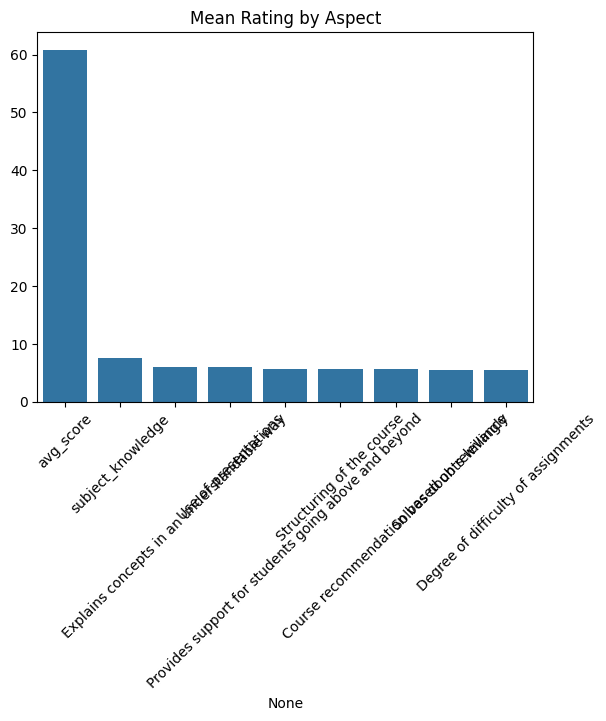

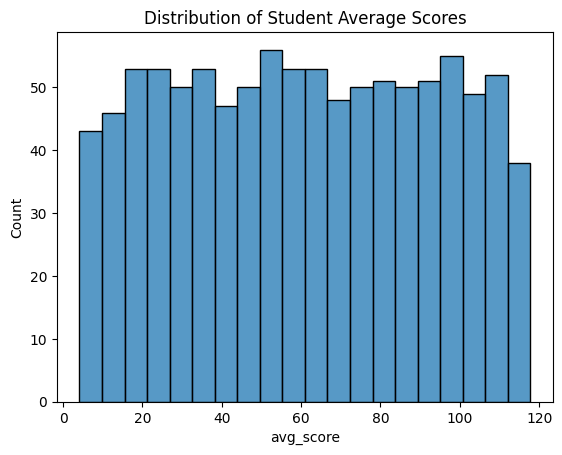

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar chart
sns.barplot(x=aspect_means.index, y=aspect_means.values)
plt.xticks(rotation=45)
plt.title("Mean Rating by Aspect")
plt.show()

# Histogram
sns.histplot(df["avg_score"], bins=20)
plt.title("Distribution of Student Average Scores")
plt.show()


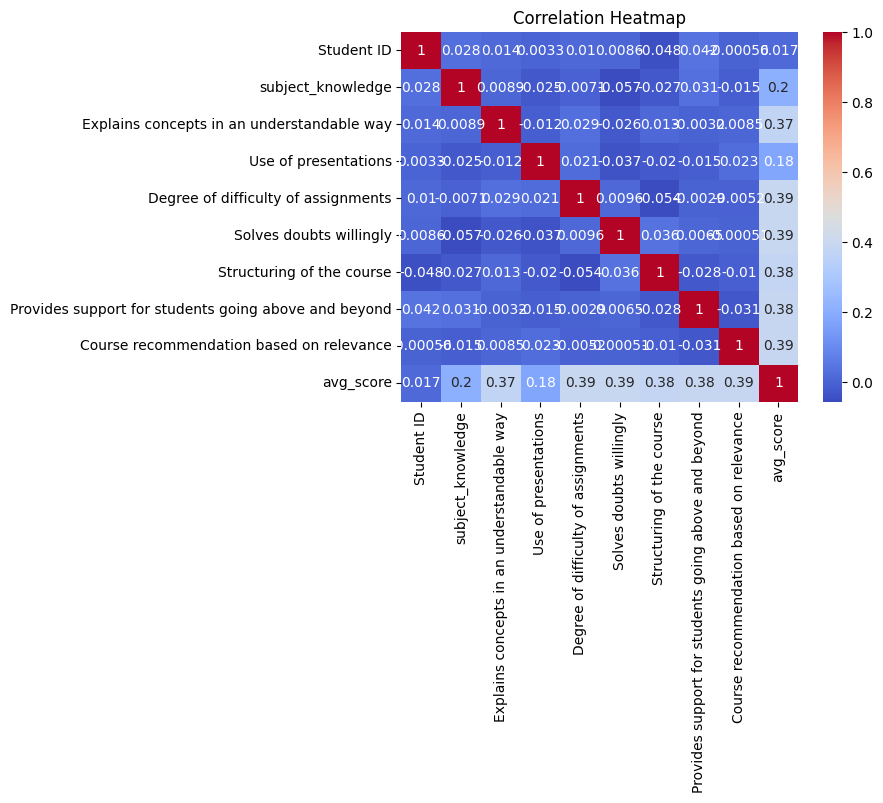

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [58]:

from google.colab import files

# Save cleaned DataFrame to CSV
df.to_csv("cleaned_feedback.csv", index=False)

# Download the file
files.download("cleaned_feedback.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
df.head()

,Student ID,subject_knowledge,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance,avg_score
0,340,5,2,7,6,9,2,1,8,5.459533
1,253,6,5,8,6,2,1,2,9,5.215363
2,680,7,7,6,5,4,2,3,1,5.301782
3,806,9,6,7,1,5,9,4,6,6.972564
4,632,8,10,8,4,6,6,9,9,8.356652
